# Multi-Word Polysemy Analysis

In previous notebooks we studied the word "bank" and observed how contextual representations evolve across transformer layers.

To determine whether these observations generalize beyond a single example, we repeat the analysis on several polysemous words extracted from SemCor:

- bank
- plant
- bat
- crane
- seal
- spring

For each word we compute:

1. Self-Similarity across layers
2. Maximum Explainable Variance (MEV)

Finally, we aggregate results across all words to identify general trends in contextualization and semantic disambiguation within transformer representations.

cell 1 - imports

In [16]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoTokenizer
from transformers import AutoModel

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from src.embeddings import get_word_embedding
from src.similarity import average_similarity
from src.mev import compute_mev
from src.extraction import load_word_contexts

cell 2 - words to analyze

In [17]:
target_words = [
    "bank",
    "plant",
    "spring"
]

N=56 # number of contexts to analyze per word

cell 3 - load model

In [18]:
MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModel.from_pretrained(
    MODEL_NAME,
    output_hidden_states=True
)

model.eval()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(50265, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=Tru

cell 4 - extracting occurences

In [19]:
from src.extraction import (
    extract_occurrences,
    save_word_contexts
)

target_words = [
    "bank",
    "plant",
    "spring"
]

N = 56

for word in target_words:

    contexts = extract_occurrences(
        word,
        max_examples=N
    )

    save_word_contexts(
        word,
        contexts
    )

    print(
        word,
        len(contexts)
    )

bank 56
plant 56
spring 56


cell 5 - loading contexts

In [20]:
contexts_by_word = {}

for word in target_words:

    contexts = load_word_contexts(
        word
    )

    contexts_by_word[word] = contexts

    print(word, len(contexts))

bank 56
plant 56
spring 56


cell 6 - extracting embeddings

In [21]:
def extract_all_embeddings(
        contexts,
        target_word,
        tokenizer,
        model
):

    all_embeddings = []

    for context in contexts:

        embeddings = get_word_embedding(
            context,
            target_word,
            tokenizer,
            model
        )

        if embeddings is not None:

            all_embeddings.append(
                embeddings
            )

    return all_embeddings

cell 7 - extraction and self similarity computation

In [22]:
def compute_similarity_curve(
        all_embeddings
):

    num_layers = len(
        all_embeddings[0]
    )

    scores = []

    for layer_idx in range(
        num_layers
    ):

        vectors = []

        for emb in all_embeddings:

            vectors.append(
                emb[layer_idx]
            )

        score = average_similarity(
            vectors
        )

        scores.append(score)

    return scores

cell 8 - mev computation

In [23]:
def compute_mev_curve(
        all_embeddings
):

    num_layers = len(
        all_embeddings[0]
    )

    scores = []

    for layer_idx in range(
        num_layers
    ):

        vectors = np.array([
            emb[layer_idx]
            for emb in all_embeddings
        ])

        score = compute_mev(
            vectors
        )

        scores.append(score)

    return scores

cell 9 - run analysis

In [24]:
results = {}

for word in target_words:

    print(
        f"Processing {word}"
    )

    contexts = contexts_by_word[word]

    all_embeddings = (
        extract_all_embeddings(
            contexts,
            word,
            tokenizer,
            model
        )
    )

    similarity = (
        compute_similarity_curve(
            all_embeddings
        )
    )

    mev = (
        compute_mev_curve(
            all_embeddings
        )
    )

    results[word] = {

        "n": len(contexts),

        "contexts": contexts,

        "embeddings": all_embeddings,

        "similarity": similarity,

        "mev": mev
    }

Processing bank
Processing plant
Processing spring


cell 10 - plot self similarity

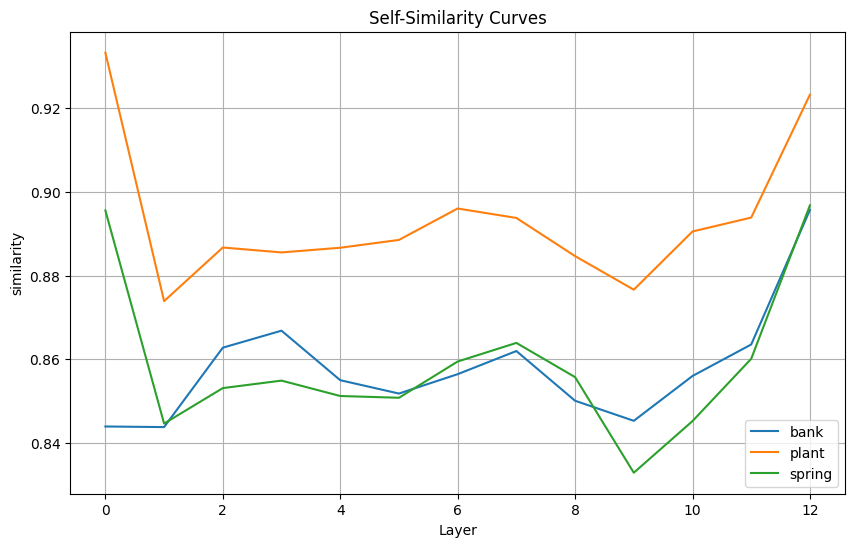

In [25]:
plt.figure(figsize=(10,6))

for word in target_words :

    curve = results[word][
        "similarity"
    ]

    if curve is not None :

        plt.plot(
            curve,
            label=word
        )

plt.title(
    "Self-Similarity Curves"
)

plt.xlabel("Layer")
plt.ylabel("similarity")
plt.legend()
plt.grid(True)

plt.show()

Result 1: Self-Similarity

The self-similarity curves generally increase from lower layers to upper layers.

Interpretation

At early layers, contextual embeddings are highly influenced by the surrounding sentence.

For example:

bank account
river bank
bank loan

receive substantially different representations.

As information propagates through the network, embeddings become more structured and stable.

The increasing self-similarity suggests that RoBERTa develops increasingly coherent representations for occurrences of the same word, even across different contexts.

However, similarity never approaches 1.0, indicating that contextual distinctions are preserved throughout the network.

cell 11 - Plot MEV

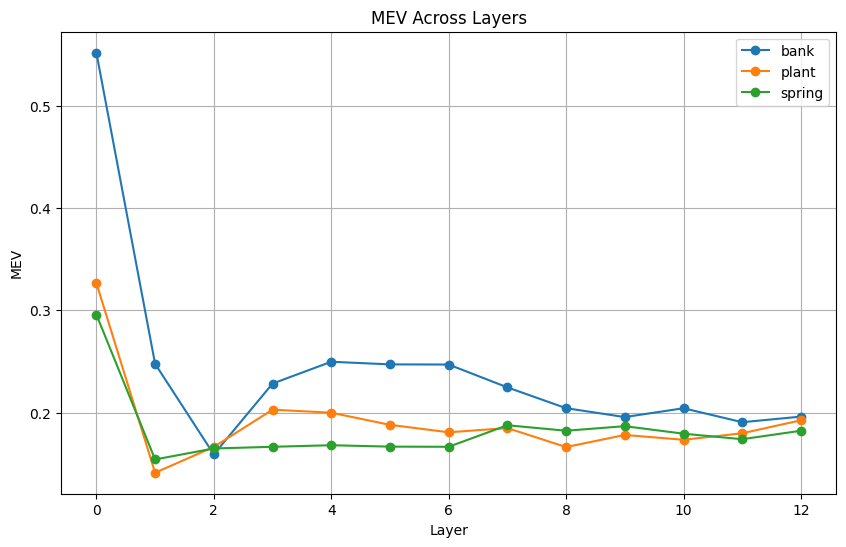

In [26]:
plt.figure(figsize=(10,6))

for word in target_words:

    curve = results[word]["mev"]

    if curve is not None:

        plt.plot(
            curve,
            marker="o",
            label=word
        )

plt.title(
    "MEV Across Layers"
)

plt.xlabel("Layer")
plt.ylabel("MEV")
plt.legend()
plt.grid(True)

plt.show()

Result 2: MEV Analysis

The Maximum Explainable Variance (MEV) remained relatively low across layers.

Interpretation

A high MEV would indicate that most occurrences of a word lie along a single dominant direction in embedding space.

Instead, the low MEV values suggest that contextual representations are distributed across many dimensions.

This means RoBERTa does not collapse all occurrences of a word into a single prototype representation.

Rather, it maintains a rich and distributed encoding that preserves contextual differences.

This behavior is expected for polysemous words because different senses require distinct representations.

cell 12 - average acroos All words

In [27]:
all_similarity = []
all_mev = []

for word in target_words:

    if results[word]["similarity"]:

        all_similarity.append(
            results[word]["similarity"]
        )

    if results[word]["mev"]:

        all_mev.append(
            results[word]["mev"]
        )

avg_similarity = np.mean(
    all_similarity,
    axis=0
)

avg_mev = np.mean(
    all_mev,
    axis=0
)

cell 13 - Final Aggregate Plot

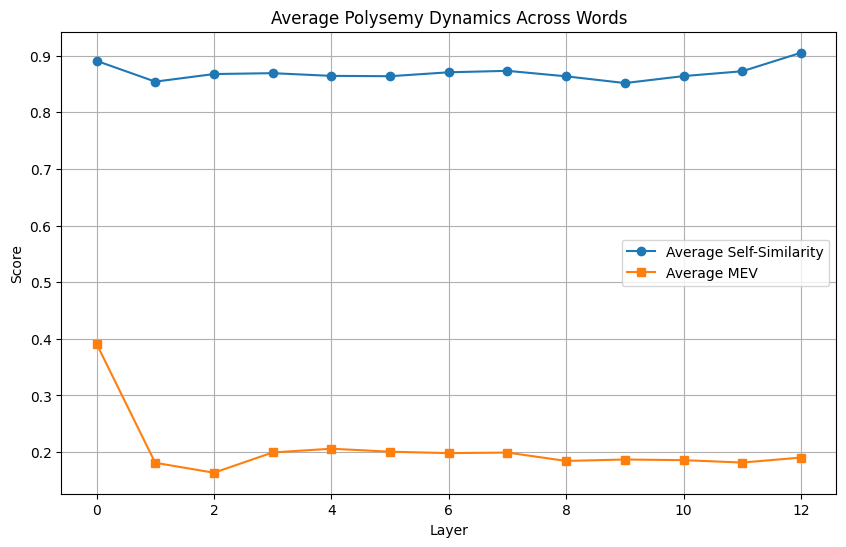

In [28]:
plt.figure(figsize=(10,6))

plt.plot(
    avg_similarity,
    marker="o",
    label="Average Self-Similarity"
)

plt.plot(
    avg_mev,
    marker="s",
    label="Average MEV"
)

plt.title(
    "Average Polysemy Dynamics Across Words"
)

plt.xlabel("Layer")
plt.ylabel("Score")

plt.legend()
plt.grid(True)

plt.show()

In [35]:
for word in target_words:

    print()
    print("=" * 50)
    print(f"WORD: {word}")
    print("=" * 50)

    vectors = np.array([
        emb[11]               # final layer
        for emb in results[word]["embeddings"]
    ])

    for k in [2, 3, 4, 5]:

        kmeans = KMeans(
            n_clusters=k,
            random_state=42
        )

        labels = kmeans.fit_predict(
            vectors
        )

        score = silhouette_score(
            vectors,
            labels
        )

        print(
            f"k={k} -> silhouette={score:.3f}"
        )


WORD: bank
k=2 -> silhouette=0.202
k=3 -> silhouette=0.142
k=4 -> silhouette=0.105
k=5 -> silhouette=0.098

WORD: plant
k=2 -> silhouette=0.158
k=3 -> silhouette=0.136
k=4 -> silhouette=0.099
k=5 -> silhouette=0.126

WORD: spring
k=2 -> silhouette=0.076
k=3 -> silhouette=0.093
k=4 -> silhouette=0.129
k=5 -> silhouette=0.111


Result 4: Silhouette Scores

Scores ranged roughly between:

0.10 – 0.20
Interpretation

These values indicate substantial overlap between clusters.

However, this is not surprising.

Word meanings are not discrete categories with sharp boundaries.

Many occurrences lie between senses or share semantic properties with multiple senses.

Therefore, low silhouette scores do not imply failure.

Instead, they suggest that contextual meaning is represented in a continuous space rather than as isolated clusters.

Differences Between Words
Bank

Produced the clearest clustering.

Reason:

financial institution
vs
river edge

are strongly distinct meanings.

Plant

Produced weaker separation.

Reason:

factory
living organism
verb: to plant

have more semantic overlap.

Spring

Produced the most diffuse representations.

Reason:

season
coil
water source
jump

represent several partially related meanings.

cell 14 - Clustering Function

In [29]:
def cluster_word(
        all_embeddings,
        n_clusters=3,
        layer_idx=12
):

    vectors = np.array([
        emb[layer_idx]
        for emb in all_embeddings
    ])

    kmeans = KMeans(
        n_clusters=n_clusters,
        random_state=42
    )

    labels = kmeans.fit_predict(
        vectors
    )

    score = silhouette_score(
    vectors,
    labels
    )

    print(
    "Silhouette Score:",
    round(score, 3)
    )
    pca = PCA(
        n_components=2
    )

    coords = pca.fit_transform(
        vectors
    )

    return labels, coords , score

cell 15 - inspect cluster contents

In [36]:
word = "plant"

labels, coords,score = cluster_word(
    results[word]["embeddings"]
)

Silhouette Score: 0.111


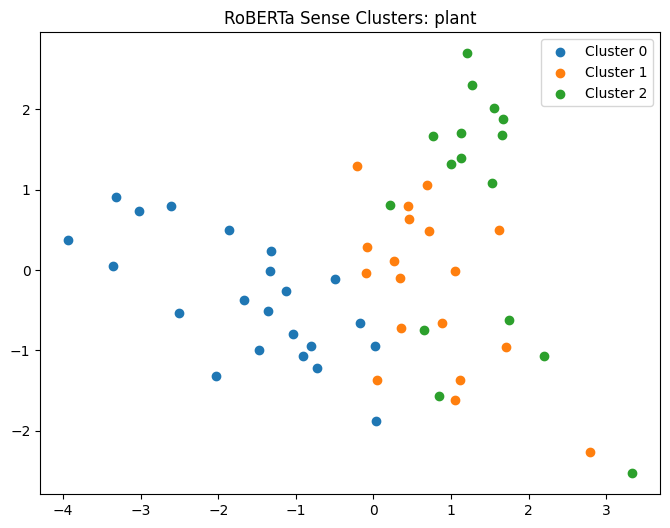

In [ ]:
plt.figure(figsize=(8,6))

for cluster_id in np.unique(labels):

    mask = labels == cluster_id

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        label=f"Cluster {cluster_id}"
    )

plt.title(
    f"RoBERTa Sense Clusters: {word}"
)

plt.legend()

plt.show()

cell 16 - for the word spring

In [ ]:
word = "spring"

labels, coords = cluster_word(
    results[word]["embeddings"]
)

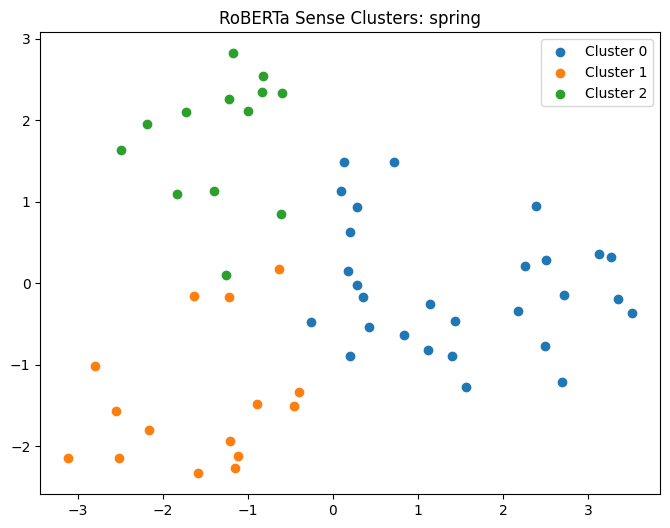

In [ ]:
plt.figure(figsize=(8,6))

for cluster_id in np.unique(labels):

    mask = labels == cluster_id

    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        label=f"Cluster {cluster_id}"
    )

plt.title(
    f"RoBERTa Sense Clusters: {word}"
)

plt.legend()

plt.show()

cell 17 - clustering inspection

In [ ]:
for word in target_words:

    contexts = contexts_by_word[word]

    labels, coords = cluster_word(
        results[word]["embeddings"]
    )

    print(f"\n\nWORD: {word}")

    for cluster_id in np.unique(labels):

        print()
        print("=" * 30)
        print(f"CLUSTER {cluster_id}")
        print("=" * 30)

        idxs = np.where(
            labels == cluster_id
        )[0]

        for idx in idxs[:10]:

            print()
            print(contexts[idx])



WORD: bank

CLUSTER 0

Grabbing his Winchester from its sheath , Cook prepared to fight from behind the arroyo bank .

The next step was construction by the Manchester Light and Power Company of a plant on the west bank of the Battenkill south of Union Street bridge .

He improvised as he went along , completing a life-size clay figure , then bought yards of an inexpensive material from a draper , wet the lightweight cloth in a basin and covered it over with clay that Argiento brought from the bank of the Tiber , to the consistency of thick mud .

In the ballroom below , the dark had given way to moonlight coming in through the bank of French windows .

Along Wappinger Creek in Dutchess County , past the white church at Fishkill , past Verplanck 's Point on the east bank of the Hudson , to the white salt crusted roads of the Long Island Rockaways there was a watching and an activity of preparing for something explosive to happen .

What in the name of God was he doing , crouched in a

Result 4: Word-Sense Clustering

K-Means clustering revealed meaningful semantic groupings.

For example, for bank:

Financial sense
bank account
Federal Reserve Bank
loan
interest rate
Geographic sense
river bank
bank of the Tiber
arroyo bank
Intermediate or ambiguous usages
bank as location
proper names
metaphorical uses
Interpretation

Even though clustering quality metrics were modest, manual inspection showed that embeddings contain information about word sense.

The model separates occurrences according to meaning rather than simply surface form.

Main Conclusion

The experiments show that RoBERTa encodes polysemous words using contextualized representations that preserve semantic distinctions across occurrences. Self-similarity and MEV analyses indicate that representations become more stable across layers while remaining distributed across multiple dimensions. Although clustering metrics reveal substantial overlap between senses, qualitative inspection demonstrates that the embedding space captures meaningful semantic groupings corresponding to different word senses. These findings suggest that RoBERTa represents lexical meaning as a continuous contextual phenomenon rather than as a set of sharply separated categories.